# Complete solution — Module 7 hands-on application

This notebook combines Sections 2–5 for end-to-end review.


# Auditing a care-management risk score

## Section 2 — Understand the data

**Work individually.** The public file is synthetic: it preserves useful
patterns for replication but contains no original patient records.


## START/RESTART HERE

Before Task 1, run every setup code cell (cells with the
`# RUN THIS CELL FIRST` label) below in order.


In [1]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
RACE_STYLES = {
    "black": {"color": "#6A3D9A", "linestyle": "--", "marker": "o"},
    "white": {"color": "#E69F00", "linestyle": "-", "marker": "s"},
}


In [2]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [3]:
# RUN THIS CELL FIRST
section_2_columns = [
    "risk_score_t",
    "cost_t",
    "gagne_sum_t",
    "race",
]
df = load_data(section_2_columns)


## Naming convention and important variables

### Naming convention

- variables ending in `_tm1` were measured in the prior year;
- variables ending in `_t` were measured in year t, when the score,
  care-management decision, or outcome is observed;
- variables starting with `dem_` are demographic fields;
- names such as `cost_emergency_tm1` record prior-year cost by care setting or
  service;
- names ending in `_elixhauser_tm1` or `_romano_tm1` are prior-year
  diagnosis-based condition indicators; and
- names ending in `_tests_tm1` count prior-year laboratory tests.

### Important variables

- `cost_t` is total medical cost in year t;
- `gagne_sum_t` is the number of active chronic conditions in year t;
- `risk_score_t` is the existing commercial score used under the current
  policy; and
- `race` denotes whether a patient self-reported as Black or White.

An *active chronic condition* is a condition recorded as present in the current
year. Here, `gagne_sum_t` is a count-based proxy for illness burden, not a
complete measure of health or treatment benefit.


## Task 1 — Inspect the data

First, check the number of observations and the number of variables in the
dataset `df`.


In [4]:
df.shape


(48784, 160)

Next, select `section_2_columns` and run `.head()` to inspect the first five
rows of the variables used in this section.


In [5]:
df[section_2_columns].head()


,risk_score_t,cost_t,gagne_sum_t,race
0,1.987430,1200.0,0,white
1,7.677934,2600.0,3,white
2,0.407678,500.0,0,white
3,0.798369,1300.0,0,white
4,17.513165,1100.0,1,white


Compute the summary statistics of `gagne_sum_t`. What are the mean and median?
What is the standard deviation? What are the minimum and maximum?


In [6]:
df["gagne_sum_t"].agg(["mean", "median", "std", "min", "max"])


mean       1.354481
median     1.000000
std        1.942488
min        0.000000
max       17.000000
Name: gagne_sum_t, dtype: float64

Plot the distribution of `gagne_sum_t` as a histogram.


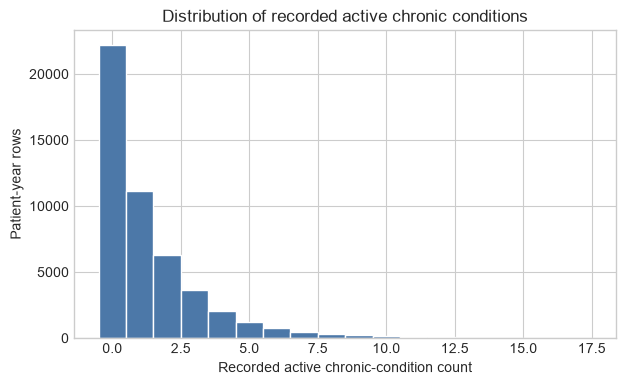

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(
    df["gagne_sum_t"].min() - 0.5,
    df["gagne_sum_t"].max() + 1.5,
    1,
)
ax.hist(
    df["gagne_sum_t"],
    bins=bins,
    color="#4C78A8",
    edgecolor="white",
)
ax.set(
    xlabel="Recorded active chronic-condition count",
    ylabel="Patient-year rows",
    title="Distribution of recorded active chronic conditions",
)
plt.show()


Compute the correlations among `gagne_sum_t`, `cost_t`, and `risk_score_t`.
Are the correlations positive or negative?


In [8]:
df[["gagne_sum_t", "cost_t", "risk_score_t"]].corr().round(3)


,gagne_sum_t,cost_t,risk_score_t
gagne_sum_t,1.000,0.355,0.570
cost_t,0.355,1.000,0.453
risk_score_t,0.570,0.453,1.000


## Task 2 — Look at the data by race

Report both the number and fraction of observations for each race.


In [9]:
race_counts = df["race"].value_counts()
race_summary = pd.DataFrame(
    {
        "observations": race_counts,
        "fraction": race_counts / len(df),
    }
)
race_summary


,observations,fraction
race,,
white,43202,0.885577
black,5582,0.114423


Compare the mean of `gagne_sum_t` by race.


In [10]:
df.groupby("race")["gagne_sum_t"].mean()


race
black    2.055536
white    1.263900
Name: gagne_sum_t, dtype: float64

Plot the distribution of `gagne_sum_t` by race.


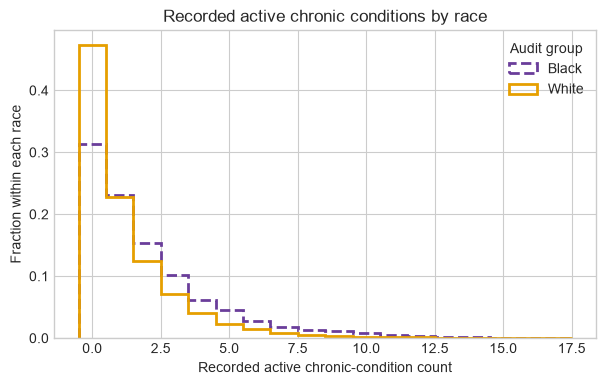

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(
    df["gagne_sum_t"].min() - 0.5,
    df["gagne_sum_t"].max() + 1.5,
    1,
)

for race, style in RACE_STYLES.items():
    values = df.loc[df["race"] == race, "gagne_sum_t"]
    ax.hist(
        values,
        bins=bins,
        weights=np.repeat(1 / len(values), len(values)),
        histtype="step",
        linewidth=2,
        label=race.title(),
        color=style["color"],
        linestyle=style["linestyle"],
    )

ax.set(
    xlabel="Recorded active chronic-condition count",
    ylabel="Fraction within each race",
    title="Recorded active chronic conditions by race",
)
ax.legend(title="Audit group")
plt.show()


## Task 3 — Identify candidate prediction features

From `df`, create a new dataset named `df_features` that contains only the
candidate prediction features:

1. Get the list of columns in `df`.
2. Create `feature_columns` by keeping columns that either end in `_tm1` or
   start with `dem_`; exclude any demographic column whose name contains
   `race`.
3. Use `feature_columns` to create `df_features`.


In [12]:
all_columns = df.columns.tolist()

feature_columns = [
    column
    for column in all_columns
    if (
        (column.endswith("_tm1"))
        or (column.startswith("dem_") and "race" not in column)
    )
]

df_features = df.loc[:, feature_columns].copy()
df_features.head()


,dem_female,dem_age_band_18-24_tm1,dem_age_band_25-34_tm1,dem_age_band_35-44_tm1,dem_age_band_45-54_tm1,dem_age_band_55-64_tm1,dem_age_band_65-74_tm1,dem_age_band_75+_tm1,alcohol_elixhauser_tm1,anemia_elixhauser_tm1,...,trig_min-low_tm1,trig_min-high_tm1,trig_min-normal_tm1,trig_mean-low_tm1,trig_mean-high_tm1,trig_mean-normal_tm1,trig_max-low_tm1,trig_max-high_tm1,trig_max-normal_tm1,gagne_sum_tm1
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,4
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Check the number of features in `df_features`.


In [13]:
df_features.shape[1]


149

Check that none of the four audit variables in `section_2_columns` entered the
candidate feature list.

Hint: use a set intersection; an empty set means no overlap.


In [14]:
set(section_2_columns) & set(feature_columns)


set()

## END-OF-SECTION CHECKPOINT — worked answer

The file has 48,784 patient-year observations and 160 variables;
`gagne_sum_t` is right-skewed (mean 1.354, median 1, standard deviation 1.942,
range 0–17), and all three pairwise correlations are positive:
`gagne_sum_t`–`cost_t` is 0.355, `gagne_sum_t`–`risk_score_t` is 0.570, and
`cost_t`–`risk_score_t` is 0.453.

White observations comprise 43,202 rows (88.56%) and Black observations 5,582
(11.44%). Mean `gagne_sum_t` is higher among Black rows (2.056 versus 1.264),
consistent with the race-specific histograms.

The 149 candidate predictors in `df_features` are prior-year `_tm1` columns
plus approved `dem_` columns excluding race. `cost_t` and `gagne_sum_t` are
later outcomes, `risk_score_t` is the existing score, and `race` is reserved
for auditing. None of the four audit variables appears in `df_features`.


# Auditing a care-management risk score

## Section 3 — Audit recorded active chronic conditions

**Question:** Among patient-year rows with similar commercial risk scores, do
Black and White patients have similar mean numbers of recorded active chronic
conditions?


## START/RESTART HERE

Before Task 1, run every setup code cell below in order. Each setup cell is
labeled `# RUN THIS CELL FIRST`; continue until you reach **Task 1**.

The setup cells import packages and load the data.


In [15]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
RACE_STYLES = {
    "black": {"color": "#6A3D9A", "linestyle": "--", "marker": "o"},
    "white": {"color": "#E69F00", "linestyle": "-", "marker": "s"},
}


In [16]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [17]:
# RUN THIS CELL FIRST
section_3_columns = ["risk_score_t", "gagne_sum_t", "race"]
df = load_data(section_3_columns)


## Variables used in this section

Each row represents one patient in one year.

- `risk_score_t`: the existing commercial score for year t. Higher values rank
  a row as higher risk under the current policy.
- `gagne_sum_t`: the number of active chronic conditions recorded in year t.
- `race`: the self-reported audit group, `black` or `white`.

You will create four additional columns or objects:

- `audit`: a smaller analysis table containing the three columns above;
- `risk_percentile`: a row's position in the pooled score distribution, from
  low to high, calculated before separating rows by race;
- `risk_bin`: one of 100 nearly equal-sized score ranges, numbered 1 to 100;
  and
- `commercial_selected`: a Boolean column that is `True` for exactly
  `number_selected = ceil(0.03 × n)` rows with the highest commercial scores.


## Task 1 — Create comparable commercial-risk ranges

### 1A — Create the analysis table

Create `audit` by selecting `section_3_columns` from `df` and making a copy.
Display its first five rows.


In [18]:
audit = df.loc[:, section_3_columns].copy()
audit.head()


,risk_score_t,gagne_sum_t,race
0,1.987430,0,white
1,7.677934,3,white
2,0.407678,0,white
3,0.798369,0,white
4,17.513165,1,white


### 1B — Put scores on a pooled percentile scale

Add `risk_percentile` to `audit`. A pooled percentile ranks all patient-year
rows together, rather than calculating separate percentiles within each race.
Rows tied on `risk_score_t` should receive the same average percentile.

**Hint:** `rank(method="average", pct=True)` returns values from 0 to 1. Multiply
by 100 to express them as percentiles.


In [19]:
audit["risk_percentile"] = (
    audit["risk_score_t"].rank(method="average", pct=True) * 100
)

audit[["risk_score_t", "risk_percentile"]].head()


,risk_score_t,risk_percentile
0,1.987430,35.462447
1,7.677934,86.026156
2,0.407678,3.571868
3,0.798369,11.230116
4,17.513165,97.589374


### 1C — Form 100 narrow score ranges

Create `stable_rank`, which orders scores from low to high and uses the original
CSV row order only to resolve ties. Then divide `stable_rank` into 100 nearly
equal-sized groups and store the group number in `audit["risk_bin"]`.

**Hints:**

- `rank(method="first")` gives tied scores different positions in their
  original row order.
- `pd.qcut(..., q=100, labels=False)` numbers groups from 0 to 99; add 1 so
  `risk_bin` runs from 1 to 100.


In [20]:
stable_rank = audit["risk_score_t"].rank(method="first")
audit["risk_bin"] = (
    pd.qcut(stable_rank, q=100, labels=False) + 1
)


### 1D — Check the score ranges

Report the number of distinct `risk_bin` values and the smallest and largest
number of rows in a bin. You should find 100 bins containing either 487 or 488
rows each.


In [21]:
bin_sizes = audit["risk_bin"].value_counts()

number_of_bins = audit["risk_bin"].nunique()
smallest_bin = bin_sizes.min()
largest_bin = bin_sizes.max()

number_of_bins, smallest_bin, largest_bin


(100, np.int64(487), np.int64(488))

## Task 2 — Compare recorded active conditions within score ranges

### 2A — Build the score-range summary table

Create a pandas DataFrame named `illness_by_risk` from `audit`. Each row of
`illness_by_risk` should summarize a group of patient-year rows that share one
`risk_bin` and one `race`; it should not represent an individual patient-year.

Both races occur in all 100 bins, so the finished DataFrame should have 200
rows and these five ordinary columns:

- `risk_bin`: the score-range number, from 1 to 100;
- `race`: the audit group, `black` or `white`;
- `risk_percentile`: the mean of the already-created pooled
  `risk_percentile` values among rows in that bin and race;
- `mean_chronic_conditions`: the mean `gagne_sum_t` among those rows; and
- `rows`: the number of patient-year rows contributing to that summary row.

Build the DataFrame with elementary operations: loop over the 100 bin numbers
and two race labels, use Boolean conditions to select the matching rows,
calculate the three summaries, append one dictionary to `summary_rows`, and
finally convert that list of dictionaries to a DataFrame.

The template supplies the loop and filtering structure. Replace the three
`...` placeholders with the calculations for the output columns.


In [22]:
summary_rows = []

for bin_number in range(1, 101):
    for race_name in ["black", "white"]:
        in_group = (
            (audit["risk_bin"] == bin_number)
            & (audit["race"] == race_name)
        )
        group_rows = audit.loc[in_group]

        summary_rows.append(
            {
                "risk_bin": bin_number,
                "race": race_name,
                "risk_percentile": group_rows["risk_percentile"].mean(),
                "mean_chronic_conditions": group_rows["gagne_sum_t"].mean(),
                "rows": len(group_rows),
            }
        )

illness_by_risk = pd.DataFrame(summary_rows)
illness_by_risk.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
1,1,white,0.535576,0.044706,425
2,2,black,1.519917,0.206349,63
3,2,white,1.456683,0.134118,425
4,3,black,2.528770,0.317460,63


### 2B — Put the summary rows in plotting order

Sort `illness_by_risk` first by `race` and then by `risk_percentile`. Display
the first five rows. The supplied plot connects rows in their current order, so
this sorting step matters.


In [23]:
illness_by_risk = illness_by_risk.sort_values(
    ["race", "risk_percentile"]
)
illness_by_risk.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
2,2,black,1.519917,0.206349,63
4,3,black,2.528770,0.317460,63
6,4,black,3.456337,0.213115,61
8,5,black,4.544282,0.279412,68


### 2C — Plot the comparison

The code cell immediately below is complete plotting code provided by the
instructor. Do not edit it. Run it only after completing 2A and 2B.

The plotting code expects `illness_by_risk` to contain the five columns defined
in 2A and to be sorted as requested in 2B. For each race, the code:

- places `risk_percentile` on the horizontal axis;
- places `mean_chronic_conditions` on the vertical axis; and
- connects the 100 score-range summaries from lower to higher commercial risk.

Each plotted point represents the mean for one `risk_bin` and `race`
combination, not an individual patient-year row. The two lines therefore
compare Black and White mean recorded condition counts across similar
commercial-risk ranges.


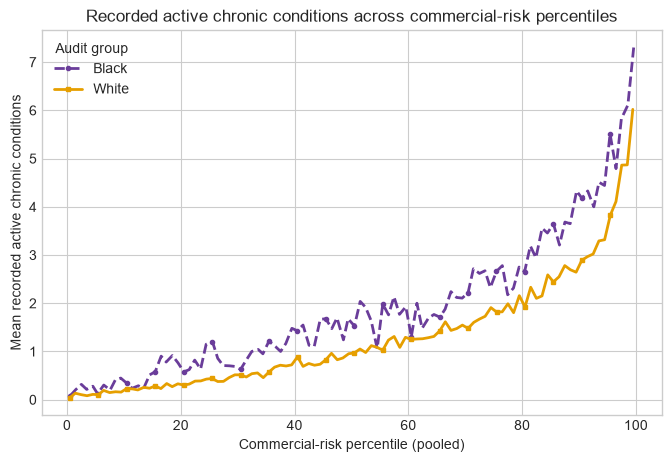

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

for race, style in RACE_STYLES.items():
    plot_data = illness_by_risk.loc[illness_by_risk["race"] == race]
    ax.plot(
        plot_data["risk_percentile"],
        plot_data["mean_chronic_conditions"],
        label=race.title(),
        linewidth=2,
        markersize=3,
        markevery=5,
        **style,
    )

ax.set(
    xlabel="Commercial-risk percentile (pooled)",
    ylabel="Mean recorded active chronic conditions",
    title="Recorded active chronic conditions across commercial-risk percentiles",
)
ax.legend(title="Audit group")
plt.show()


**Read the figure:** Describe the vertical ordering of the two series,
especially at higher percentiles. Do not rely on color alone: the Black series
uses dashed lines and circles; the White series uses solid lines and squares.

**Your observation:** [Write one or two sentences here.]


## Task 3 — Describe the fixed top-3% capacity group

The program applies one pooled capacity rule to all patient-year rows; it does
not select 3% separately within each race. The target is
`ceil(0.03 × number of rows)`, so the procedure can select a whole number of
rows. If scores tie at the selection boundary, the original CSV row number
breaks the tie.

### 3A — Translate 3% capacity into a number of rows

Create two scalar variables:

- `selection_fraction`: the decimal value `0.03`, meaning 3% of all rows in
  the pooled `audit` DataFrame; and
- `number_selected`: the integer number of rows the program can accept. Compute
  it by multiplying `selection_fraction` by `len(audit)`, rounding upward, and
  converting the result to an integer.

Display `number_selected`. With 48,784 rows, it should equal 1,464. Later steps
will use this value to select exactly 1,464 rows.

**Hint:** `np.ceil()` rounds upward but returns a floating-point value; convert
its result to `int`.


In [25]:
selection_fraction = 0.03
number_selected = int(
    np.ceil(selection_fraction * len(audit))
)
number_selected


1464

### 3B — Rank rows for the commercial decision

Create `commercial_ranking` from `risk_score_t` and the original row number.
Order higher scores first; within a tied score, order the smaller source-row
number first.

The template creates the two ranking columns. Replace the two `...` placeholders
with the appropriate sort directions (`True` or `False`).


In [26]:
commercial_ranking = audit[["risk_score_t"]].copy()
commercial_ranking["source_row"] = commercial_ranking.index
commercial_ranking = commercial_ranking.sort_values(
    ["risk_score_t", "source_row"],
    ascending=[False, True],
)
commercial_ranking.head()


,risk_score_t,source_row
10793,100.000000,10793
34164,100.000000,34164
10750,96.381858,10750
46511,95.583489,46511
16961,93.664005,16961


### 3C — Mark exactly the selected rows

Take the first `number_selected` row indices from `commercial_ranking`. Create
`commercial_selected` as `False` for every row, then change it to `True` only
for those selected indices.

Replace the two `...` placeholders, then confirm that the number of `True`
values equals `number_selected`.


In [27]:
selected_index = commercial_ranking.head(number_selected).index

audit["commercial_selected"] = False
audit.loc[selected_index, "commercial_selected"] = True

audit["commercial_selected"].sum()


np.int64(1464)

### 3D — Calculate one summary row for each race

Create `selected`, a DataFrame containing only rows where
`commercial_selected` is `True`. Then create an empty list named
`top_3_rows`.

For each race, use Boolean conditions to create:

- `race_rows`: every row in `audit` for that race; and
- `selected_race_rows`: every row in `selected` for that race.

Append one dictionary to `top_3_rows` for each race. Each dictionary should
contain:

- `race`: the race label;
- `selected_rows`: the number of rows in `selected_race_rows`;
- `fraction_of_selected`: that count divided by `len(selected)`;
- `within_race_selection_rate`: that count divided by `len(race_rows)`; and
- `mean_chronic_conditions`: mean `gagne_sum_t` in `selected_race_rows`.

The template supplies the loop and row filtering. Replace the four `...`
placeholders with the required calculations.


In [28]:
selected = audit.loc[audit["commercial_selected"]].copy()
top_3_rows = []

for race_name in ["black", "white"]:
    race_rows = audit.loc[audit["race"] == race_name]
    selected_race_rows = selected.loc[selected["race"] == race_name]

    top_3_rows.append(
        {
            "race": race_name,
            "selected_rows": len(selected_race_rows),
            "fraction_of_selected": len(selected_race_rows) / len(selected),
            "within_race_selection_rate": (
                len(selected_race_rows) / len(race_rows)
            ),
            "mean_chronic_conditions": (
                selected_race_rows["gagne_sum_t"].mean()
            ),
        }
    )


### 3E — Assemble `top_3_summary`

Convert `top_3_rows` into a pandas DataFrame named `top_3_summary`. Move its
`race` column into the index so the two data rows are labeled `black` and
`white`. Display the DataFrame rounded to four decimal places.


In [29]:
top_3_summary = pd.DataFrame(top_3_rows).set_index("race")
top_3_summary.round(4)


,selected_rows,fraction_of_selected,within_race_selection_rate,mean_chronic_conditions
race,,,,
black,293,0.2001,0.0525,6.6212
white,1171,0.7999,0.0271,5.2109


## END-OF-SECTION CHECKPOINT — worked answer

Black patient-year rows have higher mean recorded active chronic-condition
counts than White rows at many similar commercial-risk percentiles, with the
gap especially visible in the upper range. The paper describes this as a
difference in illness burden; here it is specifically a difference in the
recorded active-condition-count proxy.

The exact top 3% contains 1,464 rows. Of these, 293 (20.0%) are Black and 1,171
(80.0%) are White. About 5.25% of all Black rows are selected versus 2.71% of
all White rows. Selected Black rows average about 6.62 recorded active
conditions, compared with 5.21 for selected White rows.

The commercial score therefore does not rank the two groups equally on this
recorded health-status proxy. To be selected by the commercial algorithm, a Black patient needs to have more active chronic conditions than a White patient with the same commercial score on average.


## Alternative implementations

The worked tasks above favor explicit intermediate objects and elementary
loops for the group summaries. The same results can be obtained in other ways.

- The first alternative recreates Task 1 without pandas `rank()` or `qcut()`.
- The next two alternatives show the more compact pandas versions of the Task
  2 and Task 3 summary tables.

Separate object names are used so these examples do not replace the objects
created in the main solution.


### Alternative for Task 1 — Sorting and loops instead of `rank()` and `qcut()`

This version sorts the rows by score, walks through tied scores to calculate
their shared average percentile, and assigns the 100 bin numbers with ordinary
integer positions.


In [30]:
elementary_audit = df.loc[:, section_3_columns].copy()

ordered_rows = elementary_audit[["risk_score_t"]].copy()
ordered_rows["source_row"] = ordered_rows.index
ordered_rows = ordered_rows.sort_values(
    ["risk_score_t", "source_row"],
    ascending=[True, True],
)

row_order = ordered_rows.index.tolist()
score_order = ordered_rows["risk_score_t"].tolist()
number_of_rows = len(row_order)

percentile_for_row = {}
start = 0

while start < number_of_rows:
    stop = start

    while (
        stop + 1 < number_of_rows
        and score_order[stop + 1] == score_order[start]
    ):
        stop += 1

    first_rank = start + 1
    last_rank = stop + 1
    average_rank = (first_rank + last_rank) / 2
    percentile = (average_rank / number_of_rows) * 100

    for position in range(start, stop + 1):
        row_index = row_order[position]
        percentile_for_row[row_index] = percentile

    start = stop + 1

elementary_audit["risk_percentile"] = [
    percentile_for_row[row_index]
    for row_index in elementary_audit.index
]

bin_for_row = {}

for position, row_index in enumerate(row_order, start=1):
    bin_number = max(
        1,
        int(
            np.ceil(
                100 * (position - 1) / (number_of_rows - 1)
            )
        ),
    )
    bin_for_row[row_index] = bin_number

elementary_audit["risk_bin"] = [
    bin_for_row[row_index]
    for row_index in elementary_audit.index
]

pd.DataFrame(
    {
        "matches_rank_percentiles": [
            np.allclose(
                elementary_audit["risk_percentile"],
                audit["risk_percentile"],
            )
        ],
        "matches_qcut_bins": [
            elementary_audit["risk_bin"].equals(audit["risk_bin"])
        ],
    }
)


,matches_rank_percentiles,matches_qcut_bins
0,True,True


### Compact alternative for Task 2 — `groupby()` with `agg()`

Named aggregation can replace the nested loops from 2A. It is shorter, but it
performs the same grouping and computes the same five columns.


In [31]:
illness_by_risk_compact = (
    audit.groupby(["risk_bin", "race"], as_index=False)
    .agg(
        risk_percentile=("risk_percentile", "mean"),
        mean_chronic_conditions=("gagne_sum_t", "mean"),
        rows=("gagne_sum_t", "size"),
    )
    .sort_values(["race", "risk_percentile"])
)

illness_by_risk_compact.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
2,2,black,1.519917,0.206349,63
4,3,black,2.528770,0.317460,63
6,4,black,3.456337,0.213115,61
8,5,black,4.544282,0.279412,68


### Compact alternative for Task 3 — grouped summary Series

`value_counts()` and `groupby()` can calculate the four race-specific summary
columns without an explicit loop.


In [32]:
selected_counts = selected["race"].value_counts()
all_counts = audit["race"].value_counts()
mean_conditions = selected.groupby("race")["gagne_sum_t"].mean()

top_3_summary_compact = pd.DataFrame(
    {
        "selected_rows": selected_counts,
        "fraction_of_selected": selected_counts / len(selected),
        "within_race_selection_rate": selected_counts / all_counts,
        "mean_chronic_conditions": mean_conditions,
    }
).sort_index()

top_3_summary_compact.round(4)


,selected_rows,fraction_of_selected,within_race_selection_rate,mean_chronic_conditions
race,,,,
black,293,0.2001,0.0525,6.6212
white,1171,0.7999,0.0271,5.2109


# Auditing a care-management risk score

## Section 4 — Investigate what the score tracks

We compare realized medical cost in two ways:

1. within similar narrow commercial-risk ranges; and
2. within the same recorded active chronic-condition count.

These are descriptive comparisons. They can reveal patterns but cannot by
themselves identify every reason that spending differs.


## START/RESTART HERE

Before Task 1, run every setup code cell below in order. Each setup cell is
labeled `# RUN THIS CELL FIRST`; continue until you reach **Task 1**.

The setup cells import packages and load the data.


In [33]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
RACE_STYLES = {
    "black": {"color": "#6A3D9A", "linestyle": "--", "marker": "o"},
    "white": {"color": "#E69F00", "linestyle": "-", "marker": "s"},
}


In [34]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [35]:
# RUN THIS CELL FIRST
section_4_columns = ["risk_score_t", "cost_t", "gagne_sum_t", "race"]
df = load_data(section_4_columns)


## Variables used in this section

Each row represents one patient observed in one year.

- `risk_score_t`: the existing commercial score for year t. Larger values rank
  a row as higher commercial risk.
- `cost_t`: total realized medical cost in year t, measured in dollars.
- `gagne_sum_t`: the number of active chronic conditions recorded in year t.
  It is a recorded health-status proxy, not a complete measure of health need.
- `race`: the self-reported audit group, `black` or `white`.

All percentiles and score ranges below are pooled across race so the two groups
are compared on the same commercial-score scale.


## Task 1 — Compare future cost within narrow commercial-risk ranges

### Provided score-range setup from Section 3

Tasks 1A–1D were completed in Section 3. The complete code below recreates
the pooled commercial-risk percentiles and 100 narrow score ranges while
retaining `cost_t` for this section. Run the provided cell, then begin your
work at Task 1E.


In [36]:
# PROVIDED: score-range setup completed in Section 3
audit = df.loc[:, section_4_columns].copy()

audit["risk_percentile"] = (
    audit["risk_score_t"].rank(method="average", pct=True) * 100
)

stable_rank = audit["risk_score_t"].rank(method="first")
audit["risk_bin"] = (
    pd.qcut(stable_rank, q=100, labels=False) + 1
)

bin_sizes = audit["risk_bin"].value_counts()
number_of_bins = audit["risk_bin"].nunique()
smallest_bin = bin_sizes.min()
largest_bin = bin_sizes.max()

number_of_bins, smallest_bin, largest_bin


(100, np.int64(487), np.int64(488))

### 1E — Build `cost_by_risk`

Create a pandas DataFrame named `cost_by_risk`. Each row should summarize the
patient-year rows that share one `risk_bin` and one `race`; it should not
represent an individual patient-year.

Both races occur in all 100 bins, so the finished DataFrame should have 200
rows and these five columns:

- `risk_bin`: the score-range number;
- `race`: the audit group;
- `risk_percentile`: the arithmetic mean pooled percentile in that group;
- `mean_cost`: the arithmetic mean `cost_t`, in dollars, in that group; and
- `rows`: the number of patient-year rows contributing to that summary row.

The template loops over bins and races and selects each group with Boolean
conditions. Replace the three `...` placeholders with the required
calculations, then convert `cost_by_risk_rows` to a DataFrame.


In [37]:
cost_by_risk_rows = []

for bin_number in range(1, 101):
    for race_name in ["black", "white"]:
        in_group = (
            (audit["risk_bin"] == bin_number)
            & (audit["race"] == race_name)
        )
        group_rows = audit.loc[in_group]

        cost_by_risk_rows.append(
            {
                "risk_bin": bin_number,
                "race": race_name,
                "risk_percentile": group_rows["risk_percentile"].mean(),
                "mean_cost": group_rows["cost_t"].mean(),
                "rows": len(group_rows),
            }
        )

cost_by_risk = pd.DataFrame(cost_by_risk_rows)
cost_by_risk.head()


,risk_bin,race,risk_percentile,mean_cost,rows
0,1,black,0.553753,1033.333333,63
1,1,white,0.535576,905.176471,425
2,2,black,1.519917,1365.079365,63
3,2,white,1.456683,2959.764706,425
4,3,black,2.528770,1271.428571,63


### 1F — Sort and check `cost_by_risk`

Sort `cost_by_risk` first by `race` and then by `risk_percentile`. Confirm that
it has shape `(200, 5)` and that its `rows` column sums to all 48,784
patient-year rows. Display its first five rows.


In [38]:
cost_by_risk = cost_by_risk.sort_values(
    ["race", "risk_percentile"]
)

print("Shape:", cost_by_risk.shape)
print("Patient-year rows summarized:", cost_by_risk["rows"].sum())
cost_by_risk.head()


Shape: (200, 5)
Patient-year rows summarized: 48784


,risk_bin,race,risk_percentile,mean_cost,rows
0,1,black,0.553753,1033.333333,63
2,2,black,1.519917,1365.079365,63
4,3,black,2.528770,1271.428571,63
6,4,black,3.456337,2127.868852,61
8,5,black,4.544282,1400.000000,68


### 1G — Plot the comparison

The code cell immediately below is complete plotting code provided by the
instructor. Do not edit it. Run it after constructing and sorting
`cost_by_risk`.

The cell requires the five columns defined in 1E. Each point represents the
arithmetic mean future cost for one score-range and race group, not an
individual patient-year. The horizontal axis is mean pooled `risk_percentile`;
the vertical axis is `mean_cost`. Sorting matters because the code connects
rows in their current order.

The vertical axis uses a logarithmic display scale because the group means span
a wide range. The costs and their arithmetic means have not been
log-transformed.


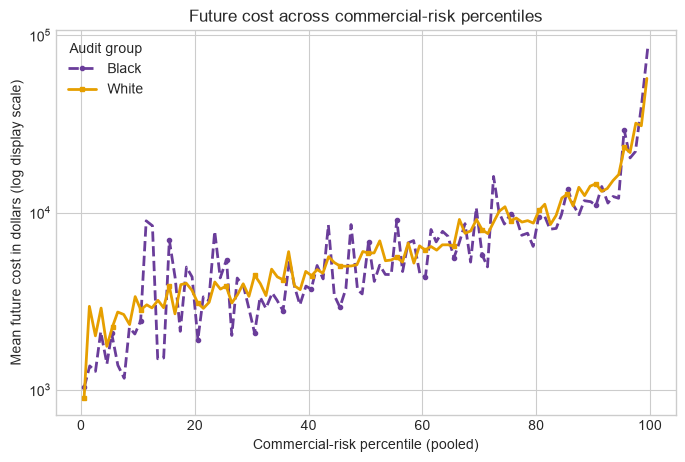

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

for race, style in RACE_STYLES.items():
    plot_data = cost_by_risk.loc[cost_by_risk["race"] == race]
    ax.plot(
        plot_data["risk_percentile"],
        plot_data["mean_cost"],
        label=race.title(),
        linewidth=2,
        markersize=3,
        markevery=5,
        **style,
    )

ax.set_yscale("log")
ax.set(
    xlabel="Commercial-risk percentile (pooled)",
    ylabel="Mean future cost in dollars (log display scale)",
    title="Future cost across commercial-risk percentiles",
)
ax.legend(title="Audit group")
plt.show()


**Answer:** The figure compares realized future costs at the same commercial
risk score, by race. Costs are approximately equal across races conditional on
score, showing that the score is well calibrated for future cost.


## Task 2 — Compare future cost at the same recorded condition count

### 2A — Pool high condition counts and count rows

Before counting rows, create `condition_group` by keeping condition counts 0
through 6 unchanged and pooling every `gagne_sum_t` value of 7 or more into
one group represented by the value 7. In the table and plot, 7 represents 7+.

Create the following objects:

- `condition_levels`: an ascending list of the distinct `condition_group` values;
  and
- `condition_counts`: an 8 × 2 pandas DataFrame. Each row represents one
  condition group, its index is `condition_group`, and its `black`
  and `white` columns contain patient-year row counts.

The template supplies the loop and DataFrame construction. Replace the two
`...` placeholders with Boolean row counts.


In [40]:
audit["condition_group"] = audit["gagne_sum_t"].clip(upper=7)
condition_levels = sorted(audit["condition_group"].unique().tolist())
condition_count_rows = []

for condition_level in condition_levels:
    at_level = audit["condition_group"] == condition_level

    black_rows = int(
        (at_level & (audit["race"] == "black")).sum()
    )
    white_rows = int(
        (at_level & (audit["race"] == "white")).sum()
    )

    condition_count_rows.append(
        {
            "condition_group": condition_level,
            "black": black_rows,
            "white": white_rows,
        }
    )

condition_counts = pd.DataFrame(condition_count_rows).set_index("condition_group")
condition_counts.columns.name = "race"
condition_counts


race,black,white
condition_group,,
0,1752,20459
1,1294,9855
2,860,5410
3,572,3093
4,344,1730
5,253,986
6,156,616
7,351,1053


### 2B — Build `cost_by_conditions`

Create a pandas DataFrame named `cost_by_conditions`. Each row should summarize
one `condition_group` and `race` combination. Because there are eight groups
for both races, the finished DataFrame should have 16 rows and these four
columns:

- `condition_group`: the recorded active chronic-condition count, with 7
  representing 7 or more;
- `race`: the audit group;
- `mean_cost`: the arithmetic mean `cost_t`, in dollars, in that group; and
- `rows`: the number of patient-year rows contributing to that summary row.

The template supplies the loops and Boolean filters. Replace the two `...`
placeholders with the required calculations.


In [41]:
cost_by_condition_rows = []

for condition_level in condition_levels:
    for race_name in ["black", "white"]:
        in_group = (
            (audit["condition_group"] == condition_level)
            & (audit["race"] == race_name)
        )
        group_rows = audit.loc[in_group]

        cost_by_condition_rows.append(
            {
                "condition_group": condition_level,
                "race": race_name,
                "mean_cost": group_rows["cost_t"].mean(),
                "rows": len(group_rows),
            }
        )

cost_by_conditions = pd.DataFrame(cost_by_condition_rows)
cost_by_conditions.head()


,condition_group,race,mean_cost,rows
0,0,black,3309.931507,1752
1,0,white,4372.520651,20459
2,1,black,5242.040185,1294
3,1,white,6440.395738,9855
4,2,black,7176.976744,860


### 2C — Sort and check `cost_by_conditions`

Sort `cost_by_conditions` first by `race` and then by `condition_group`. Confirm
that it has shape `(16, 4)` and that its `rows` column sums to all 48,784 rows
in `audit`. Display the completed table.


In [42]:
cost_by_conditions = cost_by_conditions.sort_values(
    ["race", "condition_group"]
)

print("Shape:", cost_by_conditions.shape)
print(
    "Patient-year rows summarized:",
    cost_by_conditions["rows"].sum(),
)
cost_by_conditions


Shape: (16, 4)
Patient-year rows summarized: 48784


,condition_group,race,mean_cost,rows
0,0,black,3309.931507,1752
2,1,black,5242.040185,1294
4,2,black,7176.976744,860
6,3,black,10621.153846,572
8,4,black,11261.046512,344
10,5,black,15723.715415,253
12,6,black,21571.153846,156
14,7,black,44218.233618,351
1,0,white,4372.520651,20459
3,1,white,6440.395738,9855


### 2D — Plot the comparison

The code cell immediately below is complete plotting code provided by the
instructor. Do not edit it. Run it after constructing and sorting
`cost_by_conditions`.

Each point represents arithmetic mean future cost for one pooled recorded
condition-count and race group. The horizontal axis is `condition_group`; the
vertical axis is `mean_cost` on a logarithmic display scale. The two lines
therefore compare racial groups at the same recorded condition count, with all
counts of 7 or more pooled at the final point. Sorting
matters because the plotting code connects rows in their current order.


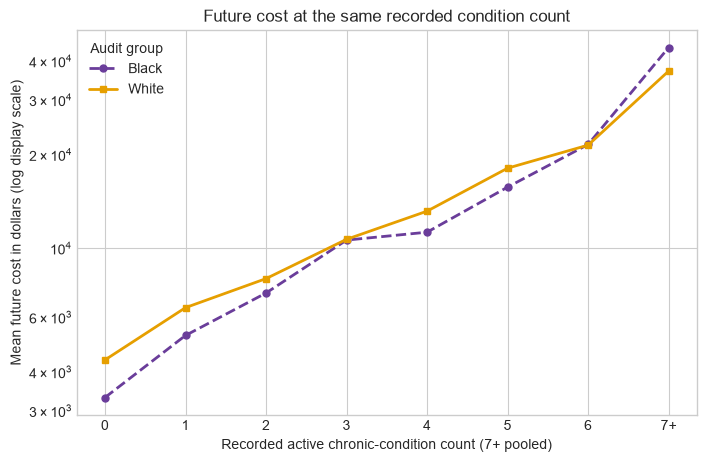

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

for race, style in RACE_STYLES.items():
    plot_data = cost_by_conditions.loc[cost_by_conditions["race"] == race]
    ax.plot(
        plot_data["condition_group"],
        plot_data["mean_cost"],
        label=race.title(),
        linewidth=2,
        markersize=5,
        **style,
    )

ax.set_yscale("log")
ax.set_xticks(range(8), ["0", "1", "2", "3", "4", "5", "6", "7+"])
ax.set(
    xlabel="Recorded active chronic-condition count (7+ pooled)",
    ylabel="Mean future cost in dollars (log display scale)",
    title="Future cost at the same recorded condition count",
)
ax.legend(title="Audit group")
plt.show()


**Answer:** Overall, Black patients spend less than White patients at the same
recorded condition burden.


## END-OF-SECTION CHECKPOINT — worked answer

The first figure compares realized future costs at the same commercial risk
score, by race. Costs are approximately equal across races conditional on
score, showing that the score is well calibrated for future cost.

The second figure shows that, overall, Black patients spend less than White
patients at the same recorded condition burden. A cost objective can therefore
under-rank health need when unequal spending is not the same as unequal illness.

This case follows Obermeyer et al. (2019), using their public synthetic data.


## Compact alternatives

The main solution used explicit loops and intermediate objects so group
membership, denominators, and row units remain visible. Pandas can produce the
same schemas more compactly.


### Compact alternative for `cost_by_risk`


In [44]:
cost_by_risk_compact = (
    audit.groupby(["risk_bin", "race"], as_index=False)
    .agg(
        risk_percentile=("risk_percentile", "mean"),
        mean_cost=("cost_t", "mean"),
        rows=("cost_t", "size"),
    )
    .sort_values(["race", "risk_percentile"])
)

cost_by_risk_compact.head()


,risk_bin,race,risk_percentile,mean_cost,rows
0,1,black,0.553753,1033.333333,63
2,2,black,1.519917,1365.079365,63
4,3,black,2.528770,1271.428571,63
6,4,black,3.456337,2127.868852,61
8,5,black,4.544282,1400.000000,68


### Compact alternative for `condition_counts` and `condition_levels`


In [45]:
condition_counts_compact = (
    audit.groupby(["condition_group", "race"])
    .size()
    .unstack(fill_value=0)
)

condition_levels_compact = condition_counts_compact.index.tolist()

condition_levels_compact


[0, 1, 2, 3, 4, 5, 6, 7]

### Compact alternative for `cost_by_conditions`


In [46]:
cost_by_conditions_compact = (
    audit.groupby(["condition_group", "race"], as_index=False)
    .agg(
        mean_cost=("cost_t", "mean"),
        rows=("cost_t", "size"),
    )
    .sort_values(["race", "condition_group"])
)

cost_by_conditions_compact


,condition_group,race,mean_cost,rows
0,0,black,3309.931507,1752
2,1,black,5242.040185,1294
4,2,black,7176.976744,860
6,3,black,10621.153846,572
8,4,black,11261.046512,344
10,5,black,15723.715415,253
12,6,black,21571.153846,156
14,7,black,44218.233618,351
1,0,white,4372.520651,20459
3,1,white,6440.395738,9855


# Label choice in a care-management algorithm

## Section 5 — Rebuild and compare the ranking

We will train one LASSO model to predict `gagne_sum_t`, the recorded active
chronic-condition count, then compare its top-3% allocation with the commercial
algorithm's top 3% on the same held-out patient-year rows.

Race is excluded from model training. It is retained only to audit who each
rule selects and how observed outcomes compare across groups.


## START/RESTART HERE

Before Task 1, run every setup code cell below in order. Each setup cell is
labeled `# RUN THIS CELL FIRST`; continue until you reach **Task 1**.

The setup imports packages, loads the data, fixes a 50/50 split and seed, and
defines the short classroom penalty grid. The full nine-value reference grid
remains visible as a comment for transparency but is not run in class.


In [47]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd


In [48]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [49]:
# RUN THIS CELL FIRST
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [50]:
# RUN THIS CELL FIRST
RANDOM_STATE = 707
TEST_SIZE = 0.5

# Full reference grid used during instructor validation:
# RELATIVE_ALPHA_GRID = np.logspace(-4, 0, 9)

# The active classroom grid keeps the validated full-grid winner and its
# immediate neighboring candidates while reducing the search to 15 fold-fits.
RELATIVE_ALPHA_GRID = np.array([1e-3, 10**-2.5, 1e-2])

required_columns = ["race", "risk_score_t", "gagne_sum_t"]
df = load_data(required_columns)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


## Task 1 — Build leakage-safe modeling data

### 1A — Choose the predictors

Create `feature_columns`, a Python list in dataset order containing:

- every prior-year variable whose name ends in `_tm1`; and
- every demographic variable whose name starts with `dem_` and does not
  contain `race`.

Display the length of the list. The verified data should produce 149 predictor
names.


In [51]:
feature_columns = [
    column
    for column in df.columns
    if (
        column.endswith("_tm1")
        or (column.startswith("dem_") and "race" not in column)
    )
]

len(feature_columns)


149

### 1B — Make the train-test split

Use one `train_test_split` call on the source-row index with
`test_size=TEST_SIZE` and `random_state=RANDOM_STATE`. Store the resulting NumPy
arrays as `train_index` and `test_index`.

Then create:

- `X_train` and `X_test`: predictor DataFrames using `feature_columns`; and
- `y_train` and `y_test`: matching `gagne_sum_t` Series.

Display the four shapes. The split should produce 24,392 rows in each half,
with 149 predictor columns.


In [52]:
train_index, test_index = train_test_split(
    df.index.to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train = df.loc[train_index, feature_columns]
X_test = df.loc[test_index, feature_columns]
y_train = df.loc[train_index, "gagne_sum_t"]
y_test = df.loc[test_index, "gagne_sum_t"]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((24392, 149), (24392, 149), (24392,), (24392,))

### 1C — Check the feature names

Print two direct Boolean checks that confirm:

1. no name in `feature_columns` contains `race`; and
2. no name in `feature_columns` ends in current-year `_t`.

Both checks should display `True`.


In [53]:
print(
    "No race feature:",
    not any("race" in column for column in feature_columns),
)
print(
    "No current-year _t feature:",
    not any(column.endswith("_t") for column in feature_columns),
)


No race feature: True
No current-year _t feature: True


## Task 2 — Train and evaluate one illness-burden LASSO

### 2A — Fit the classroom-sized search

Complete the supplied template. The `alpha_grid` line is already filled in for
class; replace each `...` in the remaining lines to create:

- `alpha_grid`: the three-value classroom grid for the LASSO penalty, scaled by
  the population standard deviation of `y_train`;
- `lasso_pipeline`: a Pipeline whose `scale` step is `StandardScaler()` and
  whose `model` step is `Lasso(alpha=1.0, max_iter=200_000, tol=0.001)`;
- `cv`: `KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)`;
- `illness_search`: a `GridSearchCV` that tunes `model__alpha`, scores with
  negative root mean squared error, uses `cv`, and sets `n_jobs=1`.

The short grid has only three values because the exhaustive search is too slow
for class and instructor validation has already confirmed that one performs
well. Fit `illness_search` with `X_train` and `y_train`. This performs 15
fold-fits plus one refit. Do not summarize `cv_results_`.


In [54]:
alpha_grid = RELATIVE_ALPHA_GRID * y_train.std(ddof=0)  # USE THIS ALPHA GRID IN CLASS

lasso_pipeline = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "model",
            Lasso(alpha=1.0, max_iter=200_000, tol=0.001),
        ),
    ]
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

illness_search = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=1,
)
illness_search.fit(X_train, y_train);


### 2B — Evaluate on the untouched test half

Create:

- `illness_predictions`: a 24,392-element NumPy array from the selected LASSO;
- `mean_baseline_predictions`: a 24,392-element array that repeats only the
  training-set mean of `gagne_sum_t`;
- `baseline_rmse`: the held-out RMSE of the training-mean predictions; and
- `lasso_rmse`: the held-out RMSE of the LASSO predictions.

Use the supplied `rmse` helper and print the two RMSE values rounded to three
decimal places. Do not report the selected alpha or construct a DataFrame just
to display the results. Does LASSO improve on the baseline algorithm that gives
every patient the same training-set mean prediction?


In [55]:
illness_predictions = illness_search.predict(X_test)
mean_baseline_predictions = np.repeat(y_train.mean(), len(y_test))

baseline_rmse = rmse(y_test, mean_baseline_predictions)
lasso_rmse = rmse(y_test, illness_predictions)

print(f"Baseline test RMSE: {baseline_rmse:.3f}")
print(f"LASSO test RMSE: {lasso_rmse:.3f}")


Baseline test RMSE: 1.939
LASSO test RMSE: 1.015


**Worked interpretation:** Held-out RMSE falls from `1.939` for the
training-mean baseline to `1.015` for LASSO, so the LASSO-based algorithm
predicts the recorded condition-count proxy more accurately. Both errors are
measured in recorded active chronic-condition-count units.


## Task 3 — Compare two fixed-capacity decisions with a random benchmark

Both policies treat the top 3% of the same 24,392 held-out rows, so each has
exactly 732 places. Run the single function below without editing it. This is
the deterministic top-fraction rule used in Section 3: larger scores receive
higher priority, and source-row order resolves any tie at the boundary.


In [56]:
def select_exact_top_fraction(scores, fraction=0.03):
    """Select the highest-scoring fraction of rows.

    Parameters
    ----------
    scores : pandas.Series
        Scores indexed by source-row identifier. Larger values receive higher
        priority.
    fraction : float, default=0.03
        Fraction of rows to select.

    Returns
    -------
    pandas.Series
        Boolean Series aligned with ``scores``, where ``True`` identifies a
        selected row.

    Notes
    -----
    The function selects ``ceil(fraction * n)`` rows. Ties at the selection
    boundary are resolved by ascending source-row index.
    """
    number_selected = int(np.ceil(fraction * len(scores)))
    ranking = pd.DataFrame(
        {"score": scores, "source_row": scores.index},
        index=scores.index,
    )
    selected_index = (
        ranking.sort_values(
            ["score", "source_row"],
            ascending=[False, True],
            kind="mergesort",
        )
        .head(number_selected)
        .index
    )

    selected = pd.Series(False, index=scores.index, name="selected")
    selected.loc[selected_index] = True
    return selected


### 3A — Apply the LASSO-based policy

Create `test_results`, a DataFrame indexed by original source row. Begin with
`race`, `risk_score_t`, and observed `gagne_sum_t` for the held-out rows. Add:

- `lasso_prediction`: an explicitly indexed Series made from
  `illness_predictions`; and
- `lasso_selected`: the Boolean Series returned by
  `select_exact_top_fraction` when applied to `lasso_prediction` with
  `fraction=0.03`.

Use the template to preserve row alignment, fill in the `...`, and print the
number selected. It should be 732.


In [57]:
test_results = df.loc[
    test_index,
    ["race", "risk_score_t", "gagne_sum_t"],
].copy()

test_results["lasso_prediction"] = pd.Series(
    illness_predictions,
    index=test_index,
)

test_results["lasso_selected"] = select_exact_top_fraction(
    test_results["lasso_prediction"],
    fraction=0.03,
)

print(
    "LASSO-selected rows:",
    test_results["lasso_selected"].sum(),
)


LASSO-selected rows: 732


### 3B — Apply the commercial-score policy

Apply `select_exact_top_fraction` to `risk_score_t` in `test_results`, again
using `fraction=0.03`. Store the resulting Boolean Series as
`commercial_selected` and print the number selected. It should also be 732.


In [58]:
test_results["commercial_selected"] = select_exact_top_fraction(
    test_results["risk_score_t"],
    fraction=0.03,
)

print(
    "Commercial-score-selected rows:",
    test_results["commercial_selected"].sum(),
)


Commercial-score-selected rows: 732


### 3C — Count treated people in each group

Create `lasso_treated` and `commercial_treated` by filtering `test_results` on
the corresponding selection indicator. Then create:

- `lasso_treated_counts`: a two-element Series with the numbers of Black and
  White patients treated by the LASSO policy; and
- `commercial_treated_counts`: the corresponding Series for the commercial
  policy.

Use `race_order` and `reindex` in the template so both Series display Black
first and White second. Print the two Series directly; do not construct a
reporting DataFrame.


In [59]:
race_order = ["black", "white"]

lasso_treated = test_results.loc[test_results["lasso_selected"]]
commercial_treated = test_results.loc[
    test_results["commercial_selected"]
]

lasso_treated_counts = (
    lasso_treated["race"]
    .value_counts()
    .reindex(race_order, fill_value=0)
)
commercial_treated_counts = (
    commercial_treated["race"]
    .value_counts()
    .reindex(race_order, fill_value=0)
)

print("LASSO policy — treated people by race")
print(lasso_treated_counts)
print("\nCommercial policy — treated people by race")
print(commercial_treated_counts)


LASSO policy — treated people by race
race
black    204
white    528
Name: count, dtype: int64

Commercial policy — treated people by race
race
black    139
white    593
Name: count, dtype: int64


### 3D — Compare observed illness burden across policies

Add a naive benchmark that treats 3% of the held-out rows uniformly at random.
Create:

- `number_treated`: the exact capacity, 732 rows;
- `random_treated`: a uniformly sampled 732-row DataFrame from `test_results`,
  using `random_state=RANDOM_STATE` so the classroom result is reproducible;
- `random_mean_gagne_by_race`: the mean observed `gagne_sum_t` for randomly
  treated Black and White patients; and
- `random_gagne_gap`: the corresponding Black-minus-White mean difference.

Also create the corresponding mean Series and gaps for the two score-based
policies:

- `lasso_mean_gagne_by_race`; and
- `commercial_mean_gagne_by_race`.

Define every gap as the Black mean minus the White mean, so a positive value
means the Black treated group has the higher observed mean. Print the random,
commercial, and LASSO mean Series and gaps directly; do not construct a
reporting DataFrame. Do the commercial-score means suggest that it prioritizes
recorded illness burden better than uniform random selection?


In [60]:
number_treated = int(np.ceil(0.03 * len(test_results)))
random_treated = test_results.sample(
    n=number_treated,
    random_state=RANDOM_STATE,
)

random_mean_gagne_by_race = (
    random_treated.groupby("race")["gagne_sum_t"]
    .mean()
    .reindex(race_order)
)

lasso_mean_gagne_by_race = (
    lasso_treated.groupby("race")["gagne_sum_t"]
    .mean()
    .reindex(race_order)
)
commercial_mean_gagne_by_race = (
    commercial_treated.groupby("race")["gagne_sum_t"]
    .mean()
    .reindex(race_order)
)

random_gagne_gap = (
    random_mean_gagne_by_race["black"]
    - random_mean_gagne_by_race["white"]
)
lasso_gagne_gap = (
    lasso_mean_gagne_by_race["black"]
    - lasso_mean_gagne_by_race["white"]
)
commercial_gagne_gap = (
    commercial_mean_gagne_by_race["black"]
    - commercial_mean_gagne_by_race["white"]
)

print("Random policy — mean gagne_sum_t by race")
print(random_mean_gagne_by_race.round(3))
print(f"Black - White gap: {random_gagne_gap:.3f}")

print("\nCommercial policy — mean gagne_sum_t by race")
print(commercial_mean_gagne_by_race.round(3))
print(f"Black - White gap: {commercial_gagne_gap:.3f}")

print("\nLASSO policy — mean gagne_sum_t by race")
print(lasso_mean_gagne_by_race.round(3))
print(f"Black - White gap: {lasso_gagne_gap:.3f}")


Random policy — mean gagne_sum_t by race
race
black    1.876
white    1.277
Name: gagne_sum_t, dtype: float64
Black - White gap: 0.599

Commercial policy — mean gagne_sum_t by race
race
black    6.712
white    5.292
Name: gagne_sum_t, dtype: float64
Black - White gap: 1.420

LASSO policy — mean gagne_sum_t by race
race
black    7.279
white    7.477
Name: gagne_sum_t, dtype: float64
Black - White gap: -0.198


## END-OF-SECTION CHECKPOINT — worked interpretation

Both policies treat 732 people. The LASSO-based policy treats 204 Black and 528
White patients, whereas the commercial policy treats 139 Black and 593 White
patients. Moving to the LASSO-based policy therefore treats 65 more Black
patients and 65 fewer White patients at the same capacity.

Under the LASSO-based policy, mean observed `gagne_sum_t` is `7.279` for Black
patients and `7.477` for White patients, giving a Black-minus-White gap of
`-0.198`. Under the commercial policy, the means are `6.712` and `5.292`,
giving a gap of `+1.420`. The LASSO policy has the smaller absolute observed
gap, but its direction reverses in this held-out sample. These group summaries
are descriptive and do not by themselves establish equitable treatment effects.

Uniform random selection produces much lower race-specific means: `1.876` for
Black patients and `1.277` for White patients, with a gap of `+0.599`. The
commercial policy therefore prioritizes patients with more recorded illness
burden than the naive random policy in both groups. Its larger racial gap also
shows that better targeting performance does not automatically imply a smaller
group disparity.

### General lessons

- Prediction algorithm is helpful to make better decisions.
- When designing/evaluating the policy based on a prediction algorithm, it is often difficult to find an outcome variable that is exactly aligned with the goal.
  - In this example, the ideal outcome variable is "the value of the program to each patient"
  - Such an ideal outcome variable is often not available because of many different reasons
- Thus, we often use a proxy outcome variable.
  - In this example, there are two seemingly reasonable proxy outcome variables:
    - The number of chronic conditions
    - The medical cost
- The choice of proxy outcome variable, or "label", affects the outcome under the policy.
  - In this example, it might be problematic to use the medical cost as a label because Black patients in the dataset spend less (so they seem to have have less values of enrollment) possibly because they could not afford it.
- We should carefully consider the choice of label.

### Note on algorithmic fairness

- In this example, we did not use race as a feature because the commercial algorithm does not use it and we want to make a fair comparison.
- In the real world, we often see some people arguing that race should not be used as a feature because it is not fair, and many policies are designed to be "race-blind".
- However, it is known that it is often not effective (actually, it is harmful) to exclude race from the feature set to guarantee fairness.
  - A reason: when the dataset has many features, some features (e.g., address) are more likely to be correlated with race. Thus, race can be still "leaked" through these features.
- If the fairness metric is clear, it is better to use race as a feature, and explicitly aim to achieve better fairness under the metric.
